In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
# Select only numerical features for clustering (drop CustomerID and Gender)
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Scale the features using StandardScaler so all are on the same scale
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print('Scaled features (first 3 rows):')
print(features_scaled[:3])

Scaled features (first 3 rows):
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]]


PART 2 ELBOW METHOD

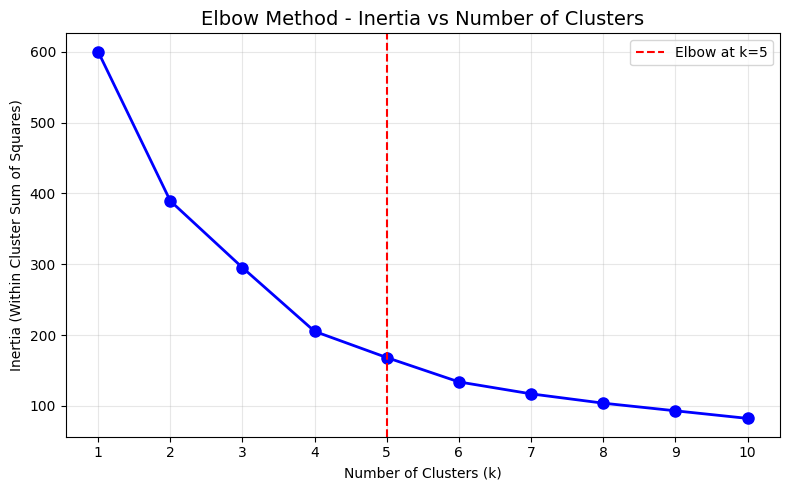

Inertia values: [600.0, 389.4, 295.2, 205.2, 168.2, 133.9, 117.0, 103.9, 93.1, 82.4]


In [10]:
# Run K-Means for k=1 to 10 and collect inertia (WCSS)
# Inertia = sum of squared distances from each point to its cluster center
# Lower inertia = tighter clusters, but adding more clusters always lowers it
# The 'elbow' is where adding more clusters stops giving big improvements

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters = k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', label='Elbow at k=5')
plt.title('Elbow Method - Inertia vs Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Inertia values:', [round(i, 1) for i in inertias])
# The curve bends noticeably at k=5, suggesting that is the optimal number

PART 3 SILHOUTTE SCORES

In [17]:
# Silhouette score measures how well each point fits its own cluster
# compared to neighboring clusters.
# Score range: -1 (bad) to +1 (great). Higher = better separation.

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    sil_scores.append(score)
    print(f'k = {k}: silhouette score = {score:.4f}')

best_k = np.argmax(sil_scores) + 2  # +2 because range starts at 2
print(f'\nHighest silhouette score at k = {best_k}: {max(sil_scores):.4f}')

k = 2: silhouette score = 0.3355
k = 3: silhouette score = 0.3578
k = 4: silhouette score = 0.4040
k = 5: silhouette score = 0.4166
k = 6: silhouette score = 0.4284
k = 7: silhouette score = 0.4172
k = 8: silhouette score = 0.4082
k = 9: silhouette score = 0.4177
k = 10: silhouette score = 0.4066

Highest silhouette score at k = 6: 0.4284


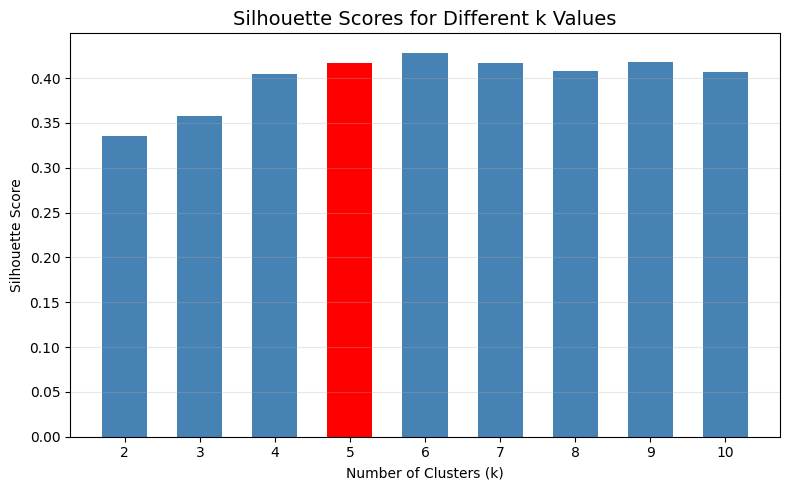

In [12]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
bar_colors = ['red' if i+2 == 5 else 'steelblue' for i in range(9)]
plt.bar(range(2, 11), sil_scores, color=bar_colors, width=0.6)
plt.title('Silhouette Scores for Different k Values', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# NOTE: Silhouette peaks at k = 5, confirming the elbow method result.
# Both methods agree: k = 5 is our optimal number of clusters.

PART 4 FINAL MODELING AND VISUALIZATON

In [13]:
# Fit final K-Means model with optimal k=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Get cluster centers in original (unscaled) scale for interpretation
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
print('Cluster centers (original scale):')
centers_df = pd.DataFrame(centers_orig,
                          columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
print(centers_df.round(1))

Cluster centers (original scale):
    Age  Annual Income (k$)  Spending Score (1-100)
0  46.2                26.8                    18.3
1  25.2                41.1                    62.2
2  32.9                86.1                    81.5
3  39.9                86.1                    19.4
4  55.6                54.4                    48.9


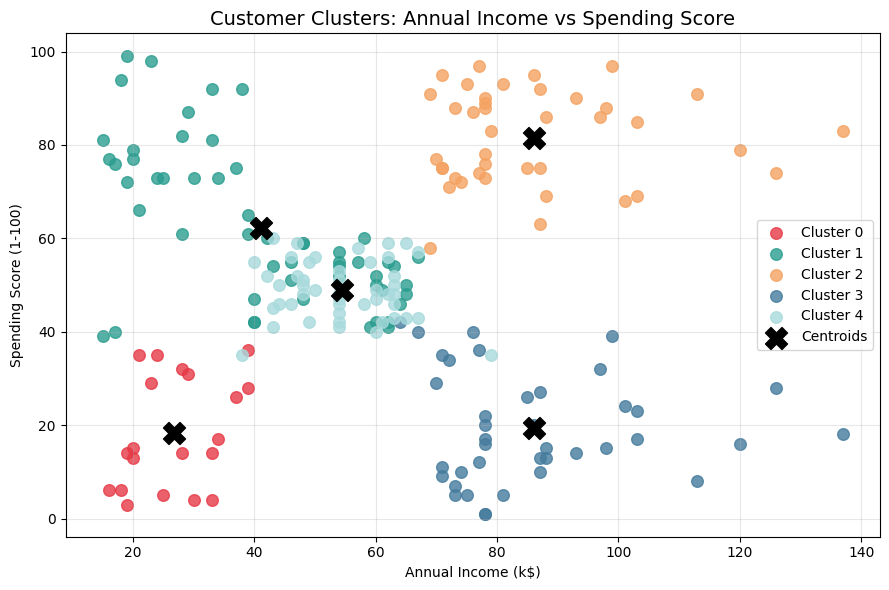

In [14]:
# 2D Scatter Plot: Annual Income vs Spending Score
COLORS = ['#E63946', '#2A9D8F', '#F4A261', '#457B9D', '#A8DADC']

plt.figure(figsize=(9, 6))
for c in range(optimal_k):
    mask = df['Cluster'] == c
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                color=COLORS[c], label=f'Cluster {c}', alpha=0.8, s=70)

# Plot cluster centers
plt.scatter(centers_orig[:, 1], centers_orig[:, 2],
            marker='X', s=250, color='black', zorder=5, label='Centroids')

plt.title('Customer Clusters: Annual Income vs Spending Score', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

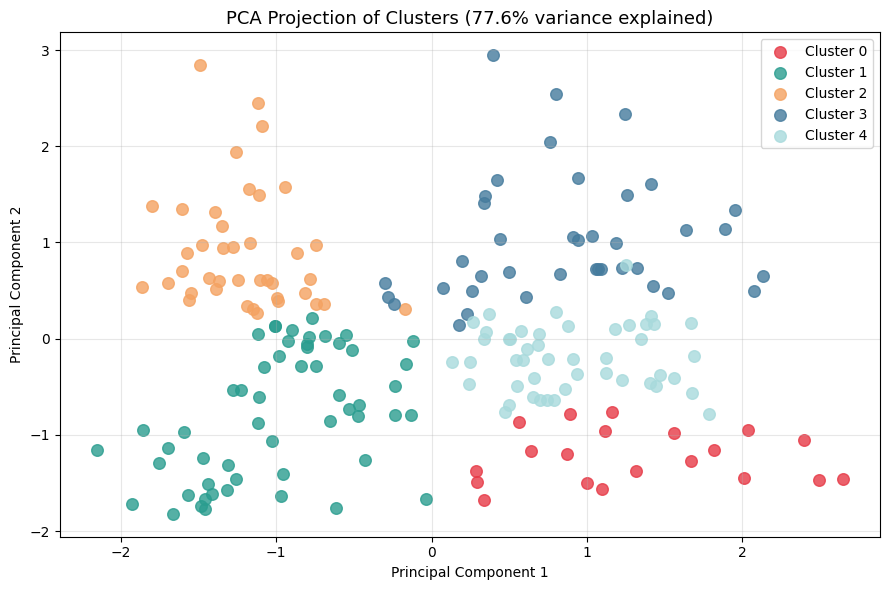

In [15]:
# PCA: Reduce 3 features to 2D for full cluster view
# PCA finds the directions of most variance — good for visualizing multidimensional clusters
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(features_scaled)

plt.figure(figsize=(9, 6))
for c in range(optimal_k):
    mask = df['Cluster'] == c
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                color=COLORS[c], label=f'Cluster {c}', alpha=0.8, s=70)

plt.title(f'PCA Projection of Clusters ({pca.explained_variance_ratio_.sum()*100:.1f}% variance explained)',
          fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PART 5

In [16]:
# Cluster summary statistics
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
summary['Count'] = df['Cluster'].value_counts().sort_index()
print(summary)

          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        46.2                26.8                    18.4     20
1        25.2                41.1                    62.2     54
2        32.9                86.1                    81.5     40
3        39.9                86.1                    19.4     39
4        55.6                54.4                    48.9     47


### Cluster Interpretation

After running K - Means with k = 5 (supported by both the elbow method and silhouette scores), five distinct customer segments emerged:

**Cluster 2 (High-Income, High Spenders)** is the most valuable segment these customers earn well and spend freely. They are prime candidates for premium loyalty programs and exclusive deals.

**Cluster 3 (High-Income, Low Spenders)** represents a significant untapped opportunity these customers have the financial capacity to spend more but aren't. Targeted engagement strategies (personalized offers, premium product showcases) could convert them into high spenders.

**Cluster 1 (Young, High Spenders)** are enthusiastic buyers despite moderate incomes, making them ideal for trend driven promotions, social media campaigns, and early access offers.

**Business Actions:**
1. **VIP Program for Cluster 2:** Launch a premium membership with exclusive perks (early sales, personalized stylist, concierge) to retain and grow the highest value customers.
2. **Re - engagement Campaign for Cluster 3:** Send personalized outreach (curated product recommendations, limited-time discounts) to high income low spenders to activate their latent purchasing power.